# Evaluation and Attribution

## Packages

In [1]:
import sys
sys.path.insert(0,'C:\\code\\python_for_the_financial_economist\\')

"""
Magic commands
"""

%load_ext autoreload
%autoreload 2

"""
Load relevant packages
"""

import pandas as pd

# working with arrays
import numpy as np

# plotting functionality
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from scipy import stats, integrate

# typehints
from typing import Tuple

"""
Own packages
"""
from codelib.visualization.base import risk_waterfall_chart, waterfall_chart

from codelib.statistics.cornish_fisher import calculate_cornish_fisher_percentile

from codelib.visualization.layout import DefaultStyle
DefaultStyle();

## Value at Risk

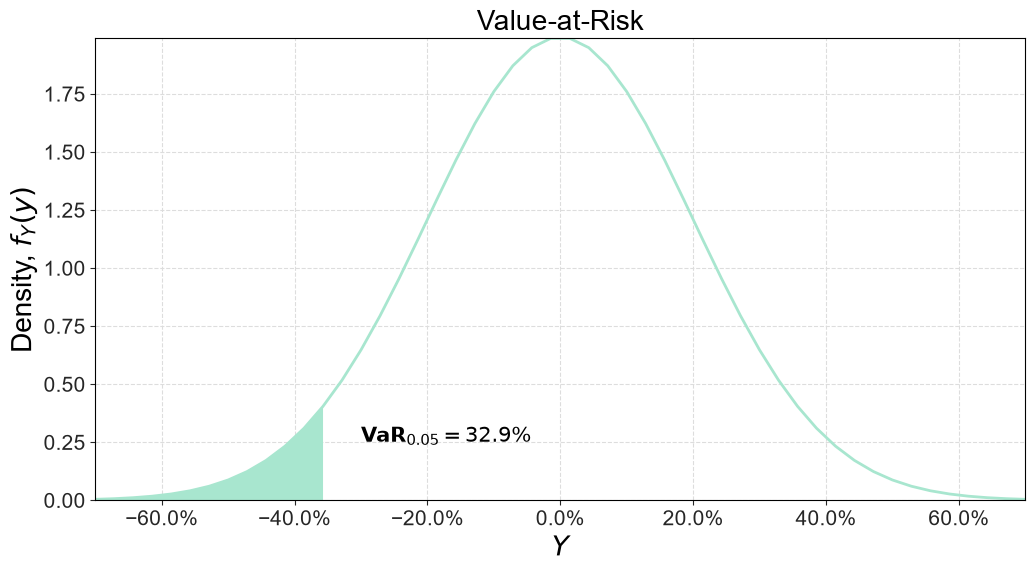

In [2]:
mu = 0.0
sigma = 0.2

# calculate 5% VaR
value_at_risk = stats.norm.ppf(0.05, loc=mu, scale=sigma)

# values for plotting the pdf
v_values = np.linspace(-0.7, 0.7)
pdf_values = stats.norm.pdf(v_values, loc=mu, scale=sigma)

"""
Plotting
"""

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(v_values, pdf_values)
ax.fill_between(v_values, pdf_values, where=v_values<value_at_risk)
ax.set_title("Value-at-Risk", size=20)
ax.set_xlabel('$Y$', size=20)
ax.set_ylabel('Density, $f_{Y}(y)$', size=20);

# add text
text_to_add =  "$\\mathbf{VaR}_{0.05}" + " = {:,.1f}\\%$".format(-value_at_risk*100)
ax.text(-0.3, 0.25, text_to_add);

# x-axis a percent
xticks = mtick.PercentFormatter(xmax=1.0, decimals=1)
ax.xaxis.set_major_formatter(xticks)

# save figure
fig.savefig("normal_value_at_risk.pdf", dpi=300, bbox_inches='tight')

### Simulation of log-normal VaR

In [3]:
"""
Define relevant information
"""

w_eq = np.array([0.5, 0.5])

mu_s = 0.06
mu_b = 0.01
sigma_s = 0.15
sigma_b = 0.075
rho = 0.2

mus = np.array([mu_s, mu_b])
vols = np.array([sigma_s, sigma_b])
corr_mat = np.array([[1.0, rho], [rho, 1.0]])
cov_mat = np.outer(vols, vols) * corr_mat

"""
Simulate
"""
num_sim = 99999
sim_log_returns = np.random.multivariate_normal(mus, cov_mat, size=num_sim)
sim_lin_returns = np.exp(sim_log_returns) - 1.0
sim_port_returns = sim_lin_returns @ w_eq

# use numpys percentile to calculate the fifth percentile (note the use of 5 and not 0.05)
value_at_risk = np.percentile(sim_port_returns, q=5)

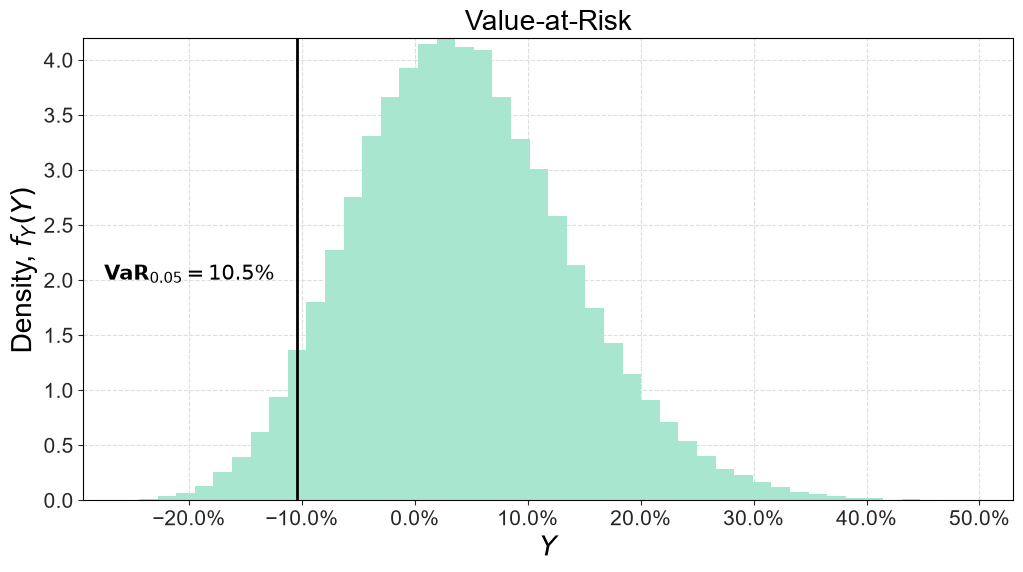

In [4]:
"""
Plotting
"""

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(sim_port_returns, density=True, bins=50)
ax.axvline(value_at_risk, ymin=0, ymax=4.1, color="black")
ax.set_title("Value-at-Risk", size=20)
ax.set_xlabel('$Y$', size=20)
ax.set_ylabel('Density, $f_{Y}(Y)$', size=20);

# add text
text_to_add =  "$\\mathbf{VaR}_{0.05}" + " = {:,.1f}\\%$".format(-value_at_risk*100)
ax.text(-0.275, 2.0, text_to_add);

# x-axis a percent
xticks = mtick.PercentFormatter(xmax=1.0, decimals=1)
ax.xaxis.set_major_formatter(xticks)

# save figure
fig.savefig("log_normal_value_at_risk.pdf", dpi=300, bbox_inches='tight')

## Cond. Value at Risk

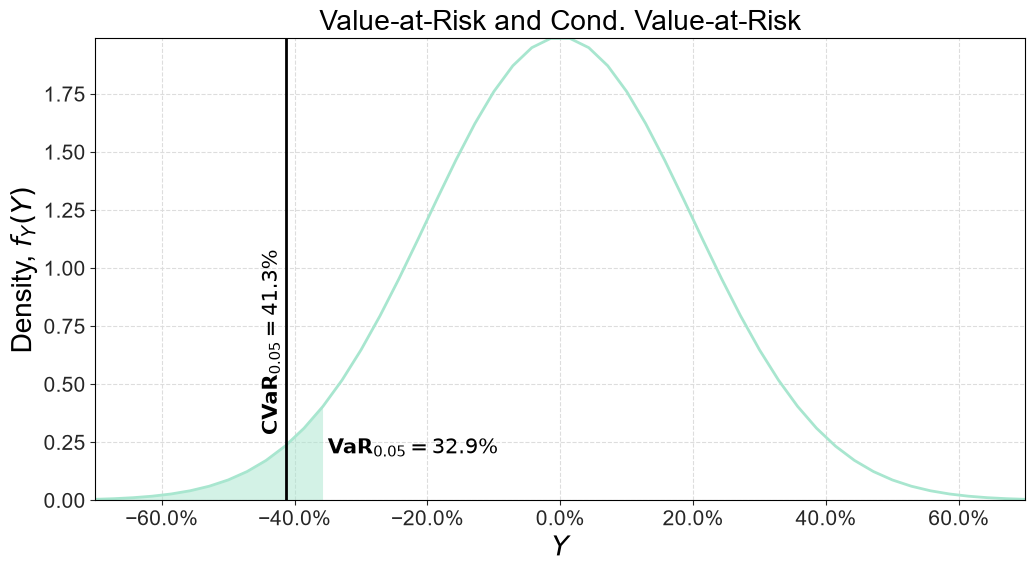

In [5]:
mu = 0.0
sigma = 0.2

# calculate 5% VaR and CVaR
value_at_risk = stats.norm.ppf(0.05, loc=mu, scale=sigma)
cond_value_at_risk = mu -  sigma*stats.norm.pdf(stats.norm.ppf(0.05)) / 0.05

# values for plotting the pdf
v_values = np.linspace(-0.7, 0.7)
pdf_values = stats.norm.pdf(v_values, loc=mu, scale=sigma)

"""
Plotting
"""

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(v_values, pdf_values)
ax.fill_between(v_values, pdf_values, where=v_values<value_at_risk, alpha=0.5)
ax.axvline(cond_value_at_risk, ymin=0, ymax=4.1, color="black")
ax.set_title("Value-at-Risk and Cond. Value-at-Risk", size=20)
ax.set_xlabel('$Y$', size=20)
ax.set_ylabel('Density, $f_{Y}(Y)$', size=20);

# add text
text_to_add =  "$\\mathbf{VaR}_{0.05}" + " = {:,.1f}\\%$".format(-value_at_risk*100)
text_to_add_2 =  "$\\mathbf{CVaR}_{0.05}" + " = {:,.1f}\\%$".format(-cond_value_at_risk*100)
ax.text(-0.35, 0.20, text_to_add);
ax.text(-0.45, 0.3, text_to_add_2,rotation=90);

# x-axis a percent
xticks = mtick.PercentFormatter(xmax=1.0, decimals=1)
ax.xaxis.set_major_formatter(xticks)


# save figure
fig.savefig("normal_cond_value_at_risk.pdf", dpi=300, bbox_inches='tight')

## Risk attribution with Homogenous Functions

### Stock-bond portfolio example

In [6]:
"""
Define relevant information
"""

w_eq = np.array([0.5, 0.5])

sigma_s = 0.15
sigma_b = 0.075
rho = 0.2

vols = np.array([sigma_s, sigma_b])
corr_mat = np.array([[1.0, rho], [rho, 1.0]])
cov_mat = np.outer(vols, vols) * corr_mat

"""
Define a function that calculates portfolio standard deviation
"""

def portfolio_std(weights: np.ndarray, cov_matrix: np.ndarray) -> float:

    """
    Calculate the standard deviation of a portfolio.

    Parameters
    ----------
    weights : np.ndarray
        Portfolio weights
    cov_matrix : np.ndarray
        Covariance matrix

    Returns
    -------
    float
        Standard deviation of portfolio
    """

    return np.sqrt(weights @ cov_matrix @ weights)

"""
Calculate diversification benefit
"""
total_port_risk = portfolio_std(w_eq, cov_mat)
div_benefit = total_port_risk - w_eq @ vols

print('The diversification benefit is equal to {:.2f}%'.format(div_benefit * 100))

The diversification benefit is equal to -2.22%


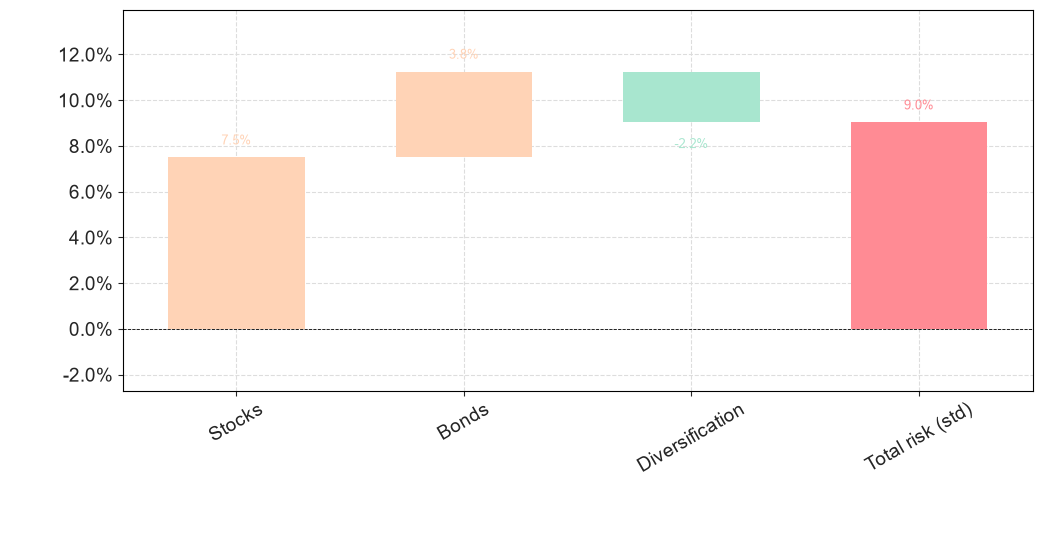

In [7]:
"""
Plot a waterfall chart with risk decomposition
"""
plt.rcParams.update({'font.size':14})

fig, ax = risk_waterfall_chart(vols * w_eq * 100, total_port_risk*100, names=["Stocks", "Bonds"],
                     formatting='{:,.1f}%', total_risk_label="Total risk (std)", diversification_label="Diversification");

fig.set_size_inches(12, 6)

# save figure
fig.savefig("waterfall_stock_bond_std.pdf", dpi=300, bbox_inches='tight')

In [8]:
def calculate_marginal_risks(weights: np.ndarray, cov_matrix: np.ndarray) -> np.ndarray:

    """
    Calculate the marginal risk of each portfolio component.

    Parameters
    ----------
    weights : np.ndarray
        Portfolio weights
    cov_matrix : np.ndarray
        Covariance matrix

    Returns
    -------
    np.ndarray
        Marginal risks
    """

    total_risk = np.sqrt(weights @ cov_matrix @ weights)
    inner_derivative = cov_matrix @ weights

    return inner_derivative / total_risk

def calculate_risk_contributions(weights: np.ndarray, cov_matrix: np.ndarray) -> np.ndarray:

    """
    Calculate the risk contribution of each portfolio component.

    Parameters
    ----------
    weights : np.ndarray
        Portfolio weights
    cov_matrix : np.ndarray
        Covariance matrix

    Returns
    -------
    np.ndarray
        Risk contributions.
    """

    mr = calculate_marginal_risks(weights, cov_matrix)

    return weights * mr

risk_contrib = calculate_risk_contributions(w_eq, cov_mat)
print("Risk contribution:")
print("Stocks: {:.2f}%'".format(risk_contrib[0] * 100))
print("Bonds: {:.2f}%'".format(risk_contrib[1] * 100))

Risk contribution:
Stocks: 6.85%'
Bonds: 2.18%'


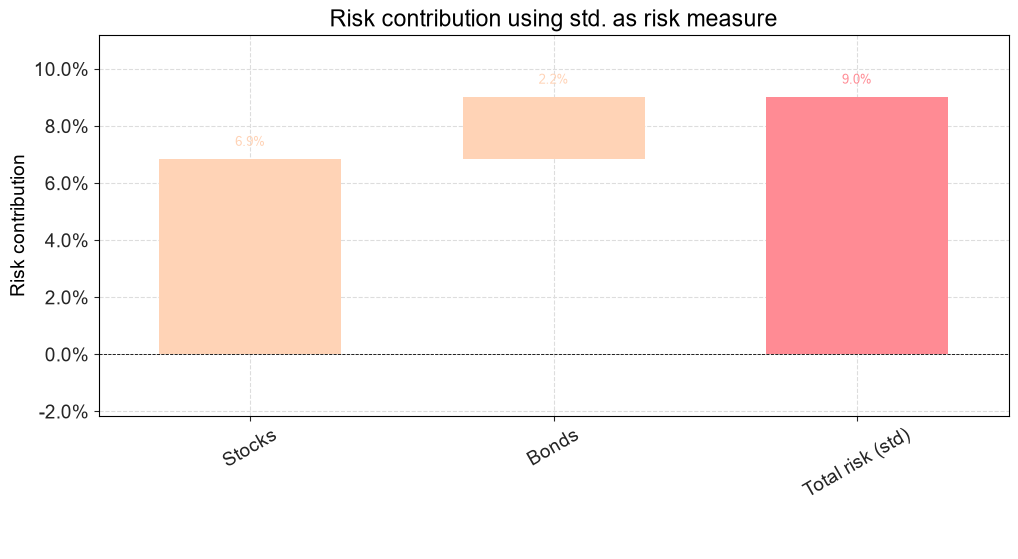

In [9]:
fig, ax = waterfall_chart(values=risk_contrib * 100,
                          labels=["Stocks", "Bonds"],
                          formatting='{:,.1f}%',
                          total_label="Total risk (std)")

ax.set(ylabel="Risk contribution", title="Risk contribution using std. as risk measure")

fig.set_size_inches(12, 6);

fig.savefig("waterfall_stock_bond_risk_contribution_std.pdf", dpi=300, bbox_inches='tight')

## General risk attribution principles

### Methods that both allow for continous and discrete functions

In [ ]:
from itertools import permutations
from math import factorial


# define one-at-a-time attribution function
def one_at_a_time_attribution(function, x):

    """
    Calculate one-at-a-time attribution values.

    Parameters
    ----------
    function : callable
        Function mapping a factor array to total performance.
    x : array-like
        Factors to attribute.

    Returns
    -------
    np.ndarray
        Attribution value for each factor when considered separately.
    """
    x = np.asarray(x)
    n = len(x)
    attribution = np.zeros(n)
    for idx in range(n):
        attribution[idx] = function(np.where(np.arange(n) == idx, x[idx], 0.0))
    return attribution

# define leave-on-out attribution function
def leave_one_out_attribution(function, x):

    """
    Calculate leave-one-out attribution values.

    Parameters
    ----------
    function : callable
        Function mapping a factor array to total performance.
    x : array-like
        Factors to attribute.

    Returns
    -------
    np.ndarray
        Reduction in total performance when each factor is excluded.
    """
    x = np.asarray(x)
    n = len(x)
    attribution = np.zeros(n)
    full_value = function(x)
    for idx in range(n):
        attribution[idx] = full_value - function(np.where(np.arange(n) == idx, 0.0, x))
    return attribution


# define sequential attribution function
def sequential_attribution(function, x):

    """
    Calculate sequential attribution values.

    Parameters
    ----------
    function : callable
        Function mapping a factor array to total performance.
    x : array-like
        Factors to attribute, in the order they should be included.

    Returns
    -------
    np.ndarray
        Incremental performance attributed to each factor.
    """
    x = np.asarray(x)
    n = len(x)
    attribution = np.zeros(n)
    included = np.zeros(n, dtype=bool)
    prev_value = function(np.where(included, x, 0.0))
    for idx in range(n):
        included[idx] = True
        new_value = function(np.where(included, x, 0.0))
        attribution[idx] = new_value - prev_value
        prev_value = new_value
    return attribution

# define attribution with Shapley values
def shapley_attribution(function, x):
    """
    Calculate attribution using Shapley values.

    Parameters
    ----------
    function : callable
        A function that takes a np.ndarray of factors (same shape as `x`, with
        factors not yet included in the coalition set to zero) and returns the
        total performance.
    x : array-like
        Array of factors contributing to the performance.

    Returns
    -------
    np.ndarray
        An array with Shapley values corresponding to the order of factors in the input array.
    """
    
    x = np.asarray(x)
    n = len(x)
    shapley_values = np.zeros(n)

    for perm in permutations(range(n)):
        included = np.zeros(n, dtype=bool)
        prev_value = function(np.where(included, x, 0.0))
        for idx in perm:
            included[idx] = True
            new_value = function(np.where(included, x, 0.0))
            marginal_contribution = new_value - prev_value
            shapley_values[idx] += marginal_contribution / factorial(n)
            prev_value = new_value

    return shapley_values


def geometric_return(weights: np.ndarray, period_returns: np.ndarray, dt: float):

    """
    Calculate the annualized geometric return of a portfolio.

    Parameters
    ----------
    weights : np.ndarray
        An array of portfolio weights.
    period_returns : np.ndarray
        Asset returns by period, with shape (n_assets, n_periods).
    dt : float
        Length of each period in years.

    Returns
    -------
    float
        The calculated performance.
    """

    horizon = period_returns.shape[1] * dt
    
    return (np.prod(1 + np.dot(weights, period_returns)))**(1 / horizon) - 1

In [11]:
np.random.seed(99)
dt = 1.0 / 12.0
horizon = 10
num_periods = int(horizon / dt)

# Simulate three asset price indices
expected_returns = np.array([0.05, 0.07, 0.06]) * dt
corr_matrix = np.array([
    [1.0, 0.5, 0.5],
    [0.5, 1.0, 0.5],
    [0.5, 0.5, 1.0]
])

vols = np.array([0.12, 0.14, 0.16]) * np.sqrt(dt)
cov_matrix = np.outer(vols, vols) * corr_matrix

# period returns
period_returns = np.random.multivariate_normal(expected_returns, cov_matrix, size=num_periods).T

# define weights
weights = np.array([0.4, 0.4, 0.2])

# performance attribution using Shapley values
performance = lambda x: geometric_return(x, period_returns, dt)
shapley_values = shapley_attribution(performance, weights)

shapley_values

array([0.02261869, 0.03028938, 0.00463175])

In [12]:
# calculate total returns
tri = np.cumprod(1 +period_returns, axis=1)

# add initial value of 1 to represent the starting point of the total return
tri = np.hstack([np.ones((tri.shape[0], 1)), tri])

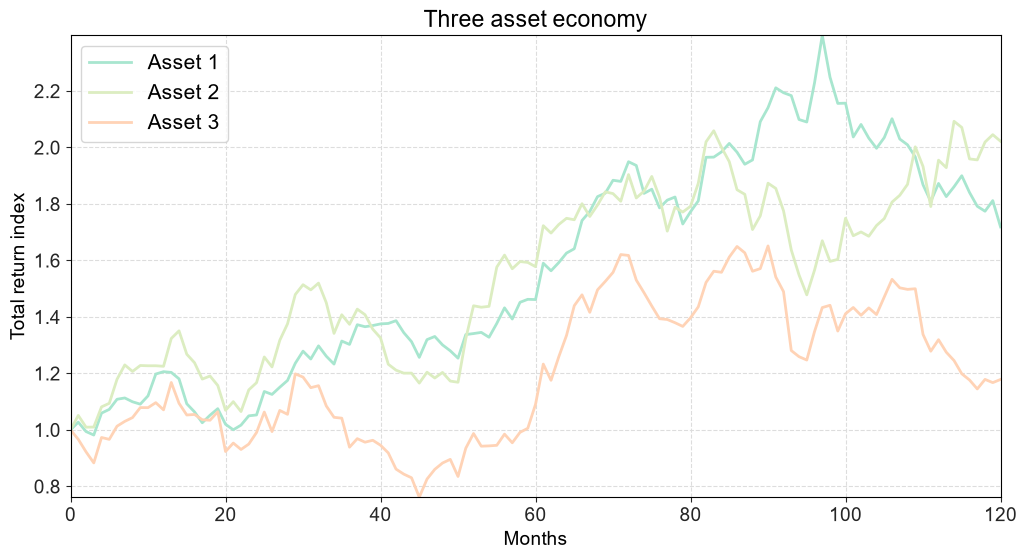

In [13]:
"""
Plot total returns over time using matplotlib
"""

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(tri.T)
ax.set_xlabel('Months')
ax.set_ylabel('Total return index')
ax.set_title('Three asset economy')

# add legend
ax.legend(['Asset 1', 'Asset 2', 'Asset 3'])

plt.savefig('total_returns_three_asset_economy.pdf')

plt.show()

In [14]:
# define weights
weights = np.array([0.4, 0.4, 0.2])

# performance attribution using Shapley values
performance = lambda x: geometric_return(x, period_returns, dt)
leave_one_out_values = leave_one_out_attribution(performance, weights)
one_at_a_time_values = one_at_a_time_attribution(performance, weights)
shapley_values = shapley_attribution(performance, weights)
sequential_values = sequential_attribution(performance, weights)

# create latex table with attribution values and sum of attribution for each method

attribution_data = {
    "Shapley": shapley_values,
    "Sequential": sequential_values,
    "Leave-One-Out": leave_one_out_values,
    "One-at-a-Time": one_at_a_time_values
}

attribution_df = pd.DataFrame(attribution_data, index=["Asset 1", "Asset 2", "Asset 3"]) * 100
attribution_df.loc["Sum"] = attribution_df.sum()
print(attribution_df.T)


print(performance(weights))

                Asset 1   Asset 2   Asset 3       Sum
Shapley        2.261869  3.028938  0.463175  5.753982
Sequential     2.361196  3.031679  0.361107  5.753982
Leave-One-Out  2.161217  2.909146  0.361107  5.431469
One-at-a-Time  2.361196  3.147404  0.563918  6.072518
0.057539822429227616


In [15]:
# Export the attribution DataFrame as a complete LaTex table.
table = attribution_df.T.copy()
table.index.name = "Method"
table = table.rename(columns={"Sum": "Sum of attributions"})

latex_tabular = (
    table.style
    .format(precision=3)
    .to_latex(
        hrules=True,
        column_format="lrrrr",
    )
)

latex_table = "\n".join(
    [
        r"\begin{table}[htbp]",
        r"    \centering",
        r"    \setlength{\tabcolsep}{10pt}",
        r"    \renewcommand{\arraystretch}{1.15}",
        latex_tabular,
        r"    \caption{Asset-level attribution values by method.}",
        r"    \label{tab:attribution-methods}",
        r"\end{table}",
    ]
)

print(latex_table)

\begin{table}[htbp]
    \centering
    \setlength{\tabcolsep}{10pt}
    \renewcommand{\arraystretch}{1.15}
\begin{tabular}{lrrrr}
\toprule
 & Asset 1 & Asset 2 & Asset 3 & Sum of attributions \\
Method &  &  &  &  \\
\midrule
Shapley & 2.262 & 3.029 & 0.463 & 5.754 \\
Sequential & 2.361 & 3.032 & 0.361 & 5.754 \\
Leave-One-Out & 2.161 & 2.909 & 0.361 & 5.431 \\
One-at-a-Time & 2.361 & 3.147 & 0.564 & 6.073 \\
\bottomrule
\end{tabular}

    \caption{Asset-level attribution values by method.}
    \label{tab:attribution-methods}
\end{table}


### Aumann-Shapley attribution

In [ ]:
def marginal_contribution(alpha, asset_idx, weights, period_returns, horizon):

    """
    Calculate an asset's marginal contribution at a scaling level.

    Parameters
    ----------
    alpha : float
        Scaling level applied to the portfolio returns.
    asset_idx : int
        Index of the asset whose contribution is calculated.
    weights : np.ndarray
        Portfolio weights.
    period_returns : np.ndarray
        Asset returns by period, with shape (n_assets, n_periods).
    horizon : float
        Investment horizon in years.

    Returns
    -------
    float
        Marginal contribution at ``alpha``.
    """

    first_term =  np.prod(1 + alpha * np.dot(weights, period_returns))**(1 / horizon)
    second_term = np.sum(np.divide(weights[asset_idx] * period_returns[asset_idx], (1 + alpha * np.dot(weights, period_returns))))

    mc = first_term * second_term

    return mc / horizon


def aumann_shapley_geometric_return(weights: np.ndarray, period_returns: np.ndarray, dt: float):

    """
    Calculate Aumann-Shapley attribution of geometric return.

    Parameters
    ----------
    weights : np.ndarray
        Portfolio weights.
    period_returns : np.ndarray
        Asset returns by period, with shape (n_assets, n_periods).
    dt : float
        Length of each period in years.

    Returns
    -------
    np.ndarray
        Aumann-Shapley attribution for each asset.
    """

    # calculate the investment horizon based on the number of periods and the time increment
    horizon = period_returns.shape[1] * dt

    # calculate the Aumann-Shapley attributions for each asset using numerical integration
    n = len(weights)
    attributions = np.zeros(n)
    for i in range(n):
        attributions[i] = integrate.quad(lambda t: marginal_contribution(t, i, weights, period_returns, horizon), 0, 1)[0]

    return attributions

In [17]:
# add Aumann-Shapley attribution to the attribution DataFrame
attribution_data["Aumann-Shapley"] = aumann_shapley_geometric_return(weights, period_returns, dt)
attribution_df = pd.DataFrame(attribution_data, index=["Asset 1", "Asset 2", "Asset 3"]) * 100
attribution_df.loc["Sum"] = attribution_df.sum()

In [18]:
attribution_df

,Shapley,Sequential,Leave-One-Out,One-at-a-Time,Aumann-Shapley
Asset 1,2.261869,2.361196,2.161217,2.361196,2.262062
Asset 2,3.028938,3.031679,2.909146,3.147404,3.028443
Asset 3,0.463175,0.361107,0.361107,0.563918,0.463476
Sum,5.753982,5.753982,5.431469,6.072518,5.753982


In [19]:
# Export the attribution DataFrame as a complete LaTex table.
table = attribution_df.T.copy()
table.index.name = "Method"
table = table.rename(columns={"Sum": "Sum of attributions"})

latex_tabular = (
    table.style
    .format(precision=3)
    .to_latex(
        hrules=True,
        column_format="lrrrr",
    )
)

latex_table = "\n".join(
    [
        r"\begin{table}[htbp]",
        r"    \centering",
        r"    \setlength{\tabcolsep}{10pt}",
        r"    \renewcommand{\arraystretch}{1.15}",
        latex_tabular,
        r"    \caption{Asset-level attribution values by method.}",
        r"    \label{tab:attribution-methods}",
        r"\end{table}",
    ]
)

print(latex_table)

\begin{table}[htbp]
    \centering
    \setlength{\tabcolsep}{10pt}
    \renewcommand{\arraystretch}{1.15}
\begin{tabular}{lrrrr}
\toprule
 & Asset 1 & Asset 2 & Asset 3 & Sum of attributions \\
Method &  &  &  &  \\
\midrule
Shapley & 2.262 & 3.029 & 0.463 & 5.754 \\
Sequential & 2.361 & 3.032 & 0.361 & 5.754 \\
Leave-One-Out & 2.161 & 2.909 & 0.361 & 5.431 \\
One-at-a-Time & 2.361 & 3.147 & 0.564 & 6.073 \\
Aumann-Shapley & 2.262 & 3.028 & 0.463 & 5.754 \\
\bottomrule
\end{tabular}

    \caption{Asset-level attribution values by method.}
    \label{tab:attribution-methods}
\end{table}
